# Box-to-box U-Net: noisy 21cm → v_z (demo)

Full pipeline in one notebook. Modules live under
`noisy_reconstruction/code/ml/`.

## Steps

1. Configure the demo (box size, seeds, noise survey).
2. Run 21cmFAST coeval cubes at the redshift where `<x_HI> ≈ 0.5`.
3. Inspect a signal cube and an observed (noisy) cube via `tuesday.core.observe_coeval`.
4. Train the 3D U-Net.
5. Evaluate: Pearson r, example slices, 1D power comparison.

In [1]:
import sys, pathlib, subprocess
PHD_ROOT = pathlib.Path().resolve().parents[2]   # .../PhD
sys.path.insert(0, str(PHD_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from noisy_reconstruction.code.ml.config import DemoConfig
from noisy_reconstruction.code.ml.noise  import observe_Tb
from noisy_reconstruction.code.ml.train  import train, load_best

cfg = DemoConfig()
cfg

DemoConfig(hii_dim=128, box_len=256.0, target_xHI=0.5, z_grid=(6.0, 7.0, 7.5, 8.0, 8.5, 9.0, 10.0), n_train=16, n_val=4, seed0=1000, survey='HERA', hera_hex_num=11, hera_split_core=True, hera_outriggers=2, hera_dish_size_m=14.0, hera_latitude_deg=-30.0, track_hours=6.0, time_per_day_hours=6.0, n_days=180, batch_size=1, epochs=40, lr=0.0002, base_channels=16, device='cuda', data_dir=PosixPath('/Users/jelte/Documents/PhD/noisy_reconstruction/data/cubes'), ckpt_dir=PosixPath('/Users/jelte/Documents/PhD/noisy_reconstruction/data/checkpoints'))

## 1. Generate 21cmFAST coeval cubes

This scans z for `<x_HI> ≈ 0.5`, then runs `n_train + n_val` realisations at
the chosen redshift with different random seeds.

Re-running is cheap — existing `sim_seed<N>.npz` files are skipped.

In [2]:
existing = sorted(cfg.data_dir.glob("sim_seed*.npz"))
need = cfg.n_total

if len(existing) < need:
    print(f"Have {len(existing)} / {need} cubes — launching 21cmFAST in a subprocess.")
    print("(output streams below; this is slow — minutes per cube)\n", flush=True)
    subprocess.run(
        [sys.executable, "-u", "-m", "noisy_reconstruction.code.ml.simulate"],
        cwd=PHD_ROOT, check=True,
    )
    existing = sorted(cfg.data_dir.glob("sim_seed*.npz"))
else:
    print(f"All {need} cubes already on disk — skipping generation.")

paths = {
    "train": existing[:cfg.n_train],
    "val":   existing[cfg.n_train:cfg.n_total],
    "z":     float(np.load(existing[0])["z"]),
}
print(f"redshift used: z = {paths['z']:.3f}")
print(f"train: {len(paths['train'])} cubes")
print(f"val:   {len(paths['val'])} cubes")

Have 0 / 20 cubes — launching 21cmFAST in a subprocess.
(output streams below; this is slow — minutes per cube)

Scanning for z at target x_HI ...


/Users/jelte/Documents/PhD/noisy_reconstruction/.venv/lib/python3.11/site-packages/attr/_make.py:3323: UserWarning: Your model (either SOURCE_MODEL=='CONST-ION-EFF' or INTEGRATION_METHOD_X=='GAMMA-APPROX')uses the EPS conditional mass function normalised to the unconditional massfunction provided by the user as matter_options.HMF
  v(inst, attr, value)


  scan: z= 6.00  <x_HI>=0.002
  scan: z= 7.00  <x_HI>=0.111
  scan: z= 7.50  <x_HI>=0.281
  scan: z= 8.00  <x_HI>=0.464
  scan: z= 8.50  <x_HI>=0.608
  scan: z= 9.00  <x_HI>=0.711
  scan: z=10.00  <x_HI>=0.839
  -> z(<x_HI>=0.5) ~ 8.124
[train] seed=1000  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1000.npz  <x_HI>=0.504  Tb_RSD std=7.77 mK  vz std=1002.2 km/s
[train] seed=1001  running 21cmFAST coeval at z=8.124 ...


/Users/jelte/Documents/PhD/noisy_reconstruction/.venv/lib/python3.11/site-packages/attr/_make.py:3323: UserWarning: Your model (either SOURCE_MODEL=='CONST-ION-EFF' or INTEGRATION_METHOD_X=='GAMMA-APPROX')uses the EPS conditional mass function normalised to the unconditional massfunction provided by the user as matter_options.HMF
  v(inst, attr, value)


        -> sim_seed1001.npz  <x_HI>=0.505  Tb_RSD std=7.76 mK  vz std=1089.1 km/s
[train] seed=1002  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1002.npz  <x_HI>=0.497  Tb_RSD std=7.77 mK  vz std=993.1 km/s
[train] seed=1003  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1003.npz  <x_HI>=0.501  Tb_RSD std=7.74 mK  vz std=899.8 km/s
[train] seed=1004  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1004.npz  <x_HI>=0.501  Tb_RSD std=7.77 mK  vz std=1062.0 km/s
[train] seed=1005  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1005.npz  <x_HI>=0.494  Tb_RSD std=7.78 mK  vz std=998.4 km/s
[train] seed=1006  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1006.npz  <x_HI>=0.503  Tb_RSD std=7.75 mK  vz std=1026.7 km/s
[train] seed=1007  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1007.npz  <x_HI>=0.501  Tb_RSD std=7.79 mK  vz std=1140.8 km/s
[train] seed=1008  running 21cmFAST coeval at z=8.124 ...
        -> sim_seed1008

## 2. Inspect one clean + one observed (noisy) cube

`observe_Tb` sends the box through `tuesday.core.observe_coeval` with
the HERA `Observation` from `noise_analysis/src/noise_filters.py`.
The returned cube *is* the uv-sampled observation with thermal noise —
not `signal + noise` bolted together.

finding redundancies: 61075ants [00:00, 2747395.08ants/s]


Tb clean    : mean=+10.86  std=7.77  mK
Tb observed : mean=+0.01  std=608.79  mK
v_z         : mean=+0.0  std=1002.2  km/s
<x_HI>      : 0.504


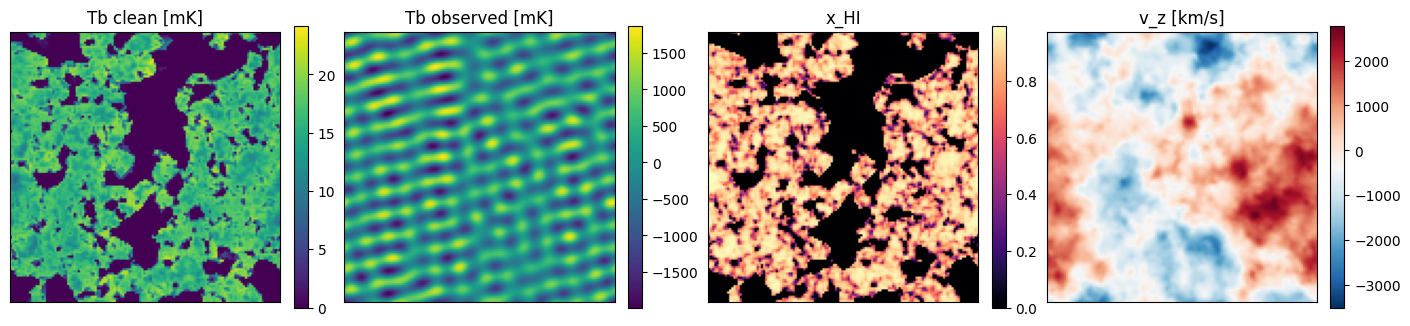

In [3]:
sample = np.load(paths['train'][0])
Tb  = sample['Tb']
xHI = sample['xHI']
vz  = sample['vz']
z   = float(sample['z'])
Tb_obs = observe_Tb(Tb, z, cfg, seed=0)

print(f"Tb clean    : mean={Tb.mean():+.2f}  std={Tb.std():.2f}  mK")
print(f"Tb observed : mean={Tb_obs.mean():+.2f}  std={Tb_obs.std():.2f}  mK")
print(f"v_z         : mean={vz.mean():+.1f}  std={vz.std():.1f}  km/s")
print(f"<x_HI>      : {xHI.mean():.3f}")

mid = cfg.hii_dim // 2
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), constrained_layout=True)
for ax, data, title, cmap in [
    (axes[0], Tb[:, :, mid],      'Tb clean [mK]',      'viridis'),
    (axes[1], Tb_obs[:, :, mid],  'Tb observed [mK]',   'viridis'),
    (axes[2], xHI[:, :, mid],     'x_HI',               'magma'),
    (axes[3], vz[:, :, mid],      'v_z [km/s]',         'RdBu_r'),
]:
    im = ax.imshow(data.T, origin='lower', cmap=cmap)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.show()

## 3. Train the U-Net

The dataset re-runs `observe_Tb` every epoch with a fresh seed, so the
network sees a different HERA noise realisation of the same signal on
each pass — free augmentation.

In [4]:
history = train(cfg, paths['train'], paths['val'])

Computing normalisation stats on 16 train cubes ...


finding redundancies: 61075ants [00:00, 2607245.83ants/s]
finding redundancies: 61075ants [00:00, 2747041.53ants/s]
finding redundancies: 61075ants [00:00, 650543.50ants/s]
finding redundancies: 61075ants [00:00, 2717953.49ants/s]
finding redundancies: 61075ants [00:00, 2752235.99ants/s]
finding redundancies: 61075ants [00:00, 2737910.46ants/s]
finding redundancies: 61075ants [00:00, 2626196.82ants/s]
finding redundancies: 61075ants [00:00, 2759321.36ants/s]
finding redundancies: 61075ants [00:00, 2691735.84ants/s]
finding redundancies: 61075ants [00:00, 2690887.59ants/s]
finding redundancies: 61075ants [00:00, 2716598.80ants/s]
finding redundancies: 61075ants [00:00, 2718068.85ants/s]
finding redundancies: 61075ants [00:00, 2713605.97ants/s]
finding redundancies: 61075ants [00:00, 2724863.23ants/s]
finding redundancies: 61075ants [00:00, 2648652.93ants/s]
finding redundancies: 61075ants [00:00, 2605919.68ants/s]


  x: mean=-0.000 std=597.251
  y: mean=0.000 std=1021.572
Using device: cpu
U-Net parameters: 5,646,385


finding redundancies: 61075ants [00:00, 2767818.27ants/s]
/Users/jelte/Documents/PhD/noisy_reconstruction/code/ml/train.py:85: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  running += float(loss) * x.size(0)
finding redundancies: 61075ants [00:00, 2682350.10ants/s]
finding redundancies: 61075ants [00:00, 2600813.41ants/s]
finding redundancies: 61075ants [00:00, 2729944.98ants/s]
finding redundancies: 61075ants [00:00, 2673950.34ants/s]
finding redundancies: 61075ants [00:00, 2686034.57ants/s]
finding redundancies: 61075ants [00:00, 2627004.78ants/s]
finding redundancies: 61075ants [00:00, 2636874.84ants/s]
finding redundancies: 61075ants [00:00, 2695162.57ants/s]
finding redundancies: 61075ants [00:00, 2699451.15ants/s]
finding redundancies: 61075ants [00:00, 27

epoch   0  train 1.0349  val 1.0051  r=-0.003  lr=2.00e-04  (91.4s)


...

epoch  37  train 0.6254  val 0.7048  r=+0.547  lr=1.23e-06  (104.9s)


finding redundancies: 61075ants [00:00, 2497656.24ants/s]
finding redundancies: 61075ants [00:00, 2520759.25ants/s]
finding redundancies: 61075ants [00:00, 2441337.64ants/s]
finding redundancies: 61075ants [00:00, 2484141.12ants/s]
finding redundancies: 61075ants [00:00, 2580248.96ants/s]
finding redundancies: 61075ants [00:00, 2459338.11ants/s]
finding redundancies: 61075ants [00:00, 2619429.59ants/s]
finding redundancies: 61075ants [00:00, 2591761.52ants/s]
finding redundancies: 61075ants [00:00, 2650927.91ants/s]
finding redundancies: 61075ants [00:00, 2587808.03ants/s]
finding redundancies: 61075ants [00:00, 2636739.13ants/s]
finding redundancies: 61075ants [00:00, 2435419.04ants/s]
finding redundancies: 61075ants [00:00, 2528247.73ants/s]
finding redundancies: 61075ants [00:00, 2566599.04ants/s]
finding redundancies: 61075ants [00:00, 2543283.23ants/s]
finding redundancies: 61075ants [00:00, 2562927.00ants/s]
finding redundancies: 61075ants [00:00, 2532021.20ants/s]
finding redund

epoch  38  train 0.6157  val 0.7073  r=+0.545  lr=3.08e-07  (106.9s)


finding redundancies: 61075ants [00:00, 442191.21ants/s]
finding redundancies: 61075ants [00:00, 2425227.85ants/s]
finding redundancies: 61075ants [00:00, 2601130.31ants/s]
finding redundancies: 61075ants [00:00, 2343899.47ants/s]
finding redundancies: 61075ants [00:00, 2510457.83ants/s]
finding redundancies: 61075ants [00:00, 2577030.27ants/s]
finding redundancies: 61075ants [00:00, 2575165.03ants/s]
finding redundancies: 61075ants [00:00, 2624421.08ants/s]
finding redundancies: 61075ants [00:00, 2561876.12ants/s]
finding redundancies: 61075ants [00:00, 2453708.02ants/s]
finding redundancies: 61075ants [00:00, 2468890.27ants/s]
finding redundancies: 61075ants [00:00, 2553830.91ants/s]
finding redundancies: 61075ants [00:00, 2411347.75ants/s]
finding redundancies: 61075ants [00:00, 2444575.98ants/s]
finding redundancies: 61075ants [00:00, 2582538.08ants/s]
finding redundancies: 61075ants [00:00, 2424975.31ants/s]
finding redundancies: 61075ants [00:00, 2511196.13ants/s]
finding redunda

epoch  39  train 0.6394  val 0.7087  r=+0.544  lr=0.00e+00  (112.7s)
done.  best val r = +0.553


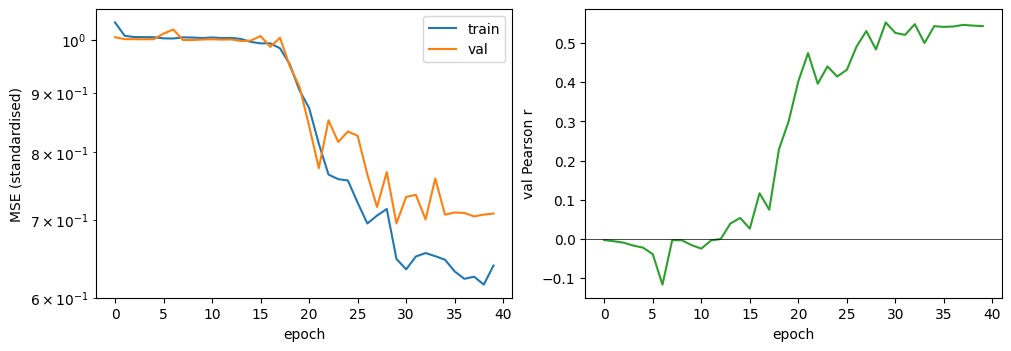

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'],   label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE (standardised)')
axes[0].set_yscale('log'); axes[0].legend()
axes[1].plot(history['val_r'], color='C2')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val Pearson r')
axes[1].axhline(0, color='k', lw=0.5)
plt.show()

## 4. Evaluate on a held-out validation cube

finding redundancies: 61075ants [00:00, 2467463.41ants/s]


voxel-level Pearson r = +0.393


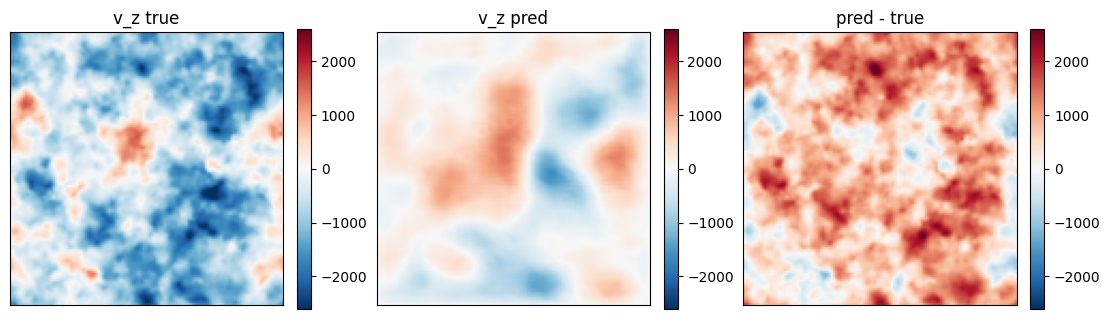

In [6]:
import torch
model, stats, device = load_best(cfg)

val = np.load(paths['val'][0])
Tb_obs  = observe_Tb(val['Tb'], float(val['z']), cfg, seed=999)
vz_true = val['vz']

x = (Tb_obs - stats.x_mean) / stats.x_std
x = torch.from_numpy(x).float().unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(x).squeeze().cpu().numpy()
vz_pred = pred * stats.y_std + stats.y_mean

r = np.corrcoef(vz_true.ravel(), vz_pred.ravel())[0, 1]
print(f'voxel-level Pearson r = {r:+.3f}')

mid = cfg.hii_dim // 2
vmax = float(np.percentile(np.abs(vz_true), 99))
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), constrained_layout=True)
for ax, data, title in [
    (axes[0], vz_true[:, :, mid], 'v_z true'),
    (axes[1], vz_pred[:, :, mid], 'v_z pred'),
    (axes[2], vz_pred[:, :, mid] - vz_true[:, :, mid], 'pred - true'),
]:
    im = ax.imshow(data.T, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.85)
plt.show()

### 1D power-spectrum comparison

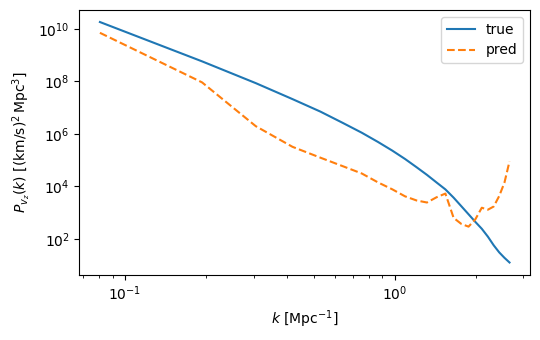

In [7]:
def _power_1d(cube, box_len):
    n = cube.shape[0]
    k1 = np.fft.fftfreq(n, d=box_len / n) * 2 * np.pi
    kx, ky, kz = np.meshgrid(k1, k1, k1, indexing='ij')
    kmag = np.sqrt(kx**2 + ky**2 + kz**2)
    fft  = np.fft.fftn(cube - cube.mean())
    pk3  = (np.abs(fft)**2) * (box_len / n)**3 / (n**3)
    bins = np.linspace(kmag[kmag > 0].min(), kmag.max(), 25)
    k_c  = 0.5 * (bins[1:] + bins[:-1])
    idx  = np.digitize(kmag.ravel(), bins)
    pk1  = np.array([pk3.ravel()[idx == i].mean() if np.any(idx == i) else np.nan
                     for i in range(1, len(bins))])
    return k_c, pk1

k, pk_true = _power_1d(vz_true, cfg.box_len)
_, pk_pred = _power_1d(vz_pred, cfg.box_len)

plt.figure(figsize=(5.5, 3.5))
plt.loglog(k, pk_true, label='true')
plt.loglog(k, pk_pred, label='pred', ls='--')
plt.xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
plt.ylabel(r'$P_{v_z}(k)\ [(\mathrm{km/s})^2\,\mathrm{Mpc}^3]$')
plt.legend(); plt.tight_layout(); plt.show()